# Miami-Dade County Property Appraisal Model

**Goal:** Build a machine learning model that predicts residential property sale prices in Miami-Dade County using real public data.

**Data Sources:**
- **NAL file** — Florida Dept. of Revenue tax roll (property characteristics: sqft, year built, assessed values)
- **SDF file** — Florida Dept. of Revenue sales data (actual transaction prices and sale details)
- **Property Point View (PPV)** — Miami-Dade Property Appraiser open data (bedrooms, bathrooms, floors)

**Approach:** Merge all three datasets on PARCEL_ID/FOLIO, clean and engineer features, then train a Random Forest model on properties under $2M.

**Best Model Result:** Random Forest — R² ≈ 0.86, MAE ≈ $68K (≈13% of median price)

---
## Phase 1: Setup & Data Loading
Load all three data sources into memory.

In [ ]:
# Mount Google Drive so Colab to access CSV files stored there
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Import libraries ──
# pandas (pd): main library for working with tabular data in Python.
#   pd.something() means calling a function from the pandas library.
#   When pandas loads a CSV, it creates a DataFrame object —
#   a spreadsheet held in memory, with rows (records) and columns (fields).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time

# scikit-learn: the standard ML library for Python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Path to project folder on Google Drive
path = '/content/drive/MyDrive/property_appraisal_project/'

# ── Load all three data sources ──
# pd.read_csv() reads the entire CSV file and loads it into memory as a
# DataFrame object. After this runs, nal/sdf/ppv hold the actual data —
# they are NOT pointers to the files. low_memory=False tells pandas to read
# the whole file at once instead of guessing column types in chunks.

# NAL: property characteristics (sqft, year built, assessed values, etc.)
nal = pd.read_csv(path + 'NAL23F202501.csv', low_memory=False)

# SDF: sales transaction records (sale price, date, qualification codes)
sdf = pd.read_csv(path + 'SDF23F202501.csv', low_memory=False)

# PPV: Property Point View from Miami-Dade open data (bedrooms, baths, floors)
ppv = pd.read_csv(path + 'PaGISView_gdb_-4277966450600873322.csv', low_memory=False)

# .shape is an ATTRIBUTE (not a method) of the DataFrame.
# It returns a tuple: (number_of_rows, number_of_columns)
print(f"NAL: {nal.shape[0]:,} rows, {nal.shape[1]} columns")
print(f"SDF: {sdf.shape[0]:,} rows, {sdf.shape[1]} columns")
print(f"PPV: {ppv.shape[0]:,} rows, {ppv.shape[1]} columns")

NAL: 933,532 rows, 165 columns
SDF: 129,047 rows, 23 columns
PPV: 942,667 rows, 42 columns


---
## Phase 2: Filtering & Merging
Filtering the sales data for quality, then merging all three datasets together on PARCEL_ID.

In [ ]:
# ── Filter SDF for qualified, single-parcel sales ──
# I only want real market transactions, not gifts, foreclosures, or symbolic sales.
#
# QUAL_CD == 1:            qualified arm's-length sale (real transaction between
#                          unrelated buyer and seller at market price)
# MULTI_PAR_SAL.isna():    NaN means it was NOT part of a multi-parcel deal.
#                          .isna() is a method that returns True where the value
#                          is missing (NaN = Not a Number, Python's version of null)
# SALE_PRC > 10000:        filters out symbolic sales ($100 transfers, etc.)
#
# .copy() creates an independent copy so I
# don't accidentally modify the original sdf DataFrame.

sdf_clean = sdf[
    (sdf['QUAL_CD'] == 1) &
    (sdf['MULTI_PAR_SAL'].isna()) &
    (sdf['SALE_PRC'] > 10000)
].copy()

print(f"Sales before filtering: {len(sdf):,}")
print(f"Sales after filtering:  {len(sdf_clean):,}")
print(f"\nSale price summary:")
print(sdf_clean['SALE_PRC'].describe())

Sales before filtering: 129,047
Sales after filtering:  51,899

Sale price summary:
count    5.189900e+04
mean     1.092665e+06
std      3.840399e+06
min      1.100000e+04
25%      3.900000e+05
50%      5.599000e+05
75%      8.540000e+05
max      4.430000e+08
Name: SALE_PRC, dtype: float64


In [ ]:
# ── Merge SDF (sales) with NAL (property characteristics) ──
# .merge() is pandas' version of a SQL JOIN. It combines two DataFrames by
# matching rows on a shared column.
#
# on='PARCEL_ID':       the column to match on (exists in both DataFrames)
# how='inner':          only keeping rows where PARCEL_ID exists in BOTH files
#                       (if a sale has no matching property record, drop it)
# suffixes=(...):       some columns exist in both files (like DOR_UC).
#                       This adds '_sale' or '_nal' to disambiguate them.

df = sdf_clean.merge(nal, on='PARCEL_ID', how='inner', suffixes=('_sale', '_nal'))

print(f"After merging SDF + NAL: {len(df):,} rows, {df.shape[1]} columns")

After merging SDF + NAL: 51,899 rows, 187 columns


In [ ]:
# ── Filter for residential properties only ──
# DOR_UC is the Florida Dept. of Revenue "Use Code" that classifies each property.
# Code 1 = Single Family Home, Code 4 = Condominium.
#
# .isin([1, 4]) checks if each value is in the list — cleaner than writing
# (df['DOR_UC_nal'] == 1) | (df['DOR_UC_nal'] == 4)

df = df[df['DOR_UC_nal'].isin([1, 4])].copy()

print(f"Residential sales: {len(df):,}")
print(f"\nBreakdown:")
print(df['DOR_UC_nal'].value_counts().rename({4: '4 (Condo)', 1: '1 (Single Family)'}))

Residential sales: 46,053

Breakdown:
DOR_UC_nal
4 (Condo)            26259
1 (Single Family)    19794
Name: count, dtype: int64


In [ ]:
# ── Build the clean features DataFrame ──
# Selecting only the columns I need and renaming them to readable names.
# This is my "working table" from this point forward

features = df[[
    'PARCEL_ID', 'SALE_PRC', 'SALE_YR', 'SALE_MO',
    'TOT_LVG_AREA', 'LND_SQFOOT', 'ACT_YR_BLT', 'EFF_YR_BLT',
    'JV', 'LND_VAL', 'NO_BULDNG', 'PHY_ZIPCD',
    'NBRHD_CD_nal', 'DOR_UC_nal', 'PHY_ADDR1'
]].copy()

features.columns = [
    'parcel_id', 'sale_price', 'sale_year', 'sale_month',
    'living_sqft', 'lot_sqft', 'year_built', 'eff_year_built',
    'just_value', 'land_value', 'num_buildings', 'zip_code',
    'neighborhood', 'property_type', 'address'
]

# Drop rows missing critical fields
# .dropna() removes rows where specified columns have NaN values
features = features.dropna(subset=['sale_price', 'living_sqft', 'year_built'])

# Removing extreme outliers that would distort the model
features = features[
    (features['sale_price'] > 50000) &
    (features['sale_price'] < 10000000) &
    (features['living_sqft'] > 200) &
    (features['living_sqft'] < 15000)
]

print(f"Clean dataset: {features.shape[0]:,} rows, {features.shape[1]} columns")
print(f"\nSale price — median: ${features['sale_price'].median():,.0f}, "
      f"mean: ${features['sale_price'].mean():,.0f}")
print(f"Living sqft — median: {features['living_sqft'].median():,.0f}, "
      f"mean: {features['living_sqft'].mean():,.0f}")

Clean dataset: 45,691 rows, 15 columns

Sale price — median: $545,000, mean: $829,830
Living sqft — median: 1,435, mean: 1,627


In [ ]:
# ── Merge in bedrooms/bathrooms/floors from Property Point View ──
# The NAL file from the state doesn't include bedroom/bathroom counts.
# I found this data in Miami-Dade's open data portal (Property Point View).
# The PPV file uses 'FOLIO' as its property ID, which matches 'parcel_id'.

# Convert FOLIO from float to int so it matches parcel_id format
ppv['folio_int'] = ppv['FOLIO'].dropna().astype(int)

# Select only the columns I need from PPV
ppv_cols = ppv[['folio_int', 'Bedroom Count', 'Bath Count',
                'Half Bath Count', 'Floor Count']].copy()

# Merge: left_on/right_on lets me join columns with different names.
# how='left' keeps ALL features rows, filling NaN where PPV has no match.
features = features.merge(ppv_cols, left_on='parcel_id',
                          right_on='folio_int', how='left')

# Remove duplicates that can occur when one FOLIO has multiple PPV records
features = features.drop_duplicates(subset='parcel_id', keep='first')

# Drop the extra folio_int column since it's redundant with parcel_id
features = features.drop(columns=['folio_int'])

# Check match rate
matched = features['Bedroom Count'].notna().sum()
print(f"PPV match rate: {matched:,} / {len(features):,} ({matched/len(features)*100:.1f}%)")

# Fill the small number of unmatched rows with median values
# .fillna() replaces NaN with the specified value
for col in ['Bedroom Count', 'Bath Count', 'Half Bath Count', 'Floor Count']:
    features[col] = features[col].fillna(features[col].median())

print(f"\nNew columns summary:")
for col in ['Bedroom Count', 'Bath Count', 'Half Bath Count', 'Floor Count']:
    print(f"  {col}: mean={features[col].mean():.1f}")

PPV match rate: 44,521 / 44,601 (99.8%)

New columns summary:
  Bedroom Count: mean=2.6
  Bath Count: mean=2.0
  Half Bath Count: mean=0.2
  Floor Count: mean=0.7


---
## Phase 3: Feature Engineering
Creating new columns from existing data to help the model make better predictions.

In [ ]:
# ── Create engineered features ──
# These are new columns I calculated from existing data. Feature engineering
# is where domain knowledge matters — I am telling the model what relationships
# might be important.

# Building age: how old the structure is (2025 minus year it was built)
from datetime import datetime
CURRENT_YEAR = datetime.now().year

features['building_age'] = CURRENT_YEAR - features['year_built']
features['eff_age'] = CURRENT_YEAR - features['eff_year_built']

raw_age = CURRENT_YEAR - features['year_built']
features['age_tier'] = pd.cut(
    raw_age,
    bins=[-1, 10, 40, 75, 200], # <-- Comma added here!
    labels=['New_Construction', 'Modern', 'Mid_Century', 'Historic']
)

# Price per square foot: useful for EDA, but excluded from model input
# because it's calculated FROM sale_price
features['price_per_sqft'] = features['sale_price'] / features['living_sqft']

# Is condo: converts property_type (1 or 4) into a binary 0/1 flag.
# .astype(int) converts True/False into 1/0.
features['is_condo'] = (features['property_type'] == 4).astype(int)

# Total bathrooms: full baths + half baths counted as 0.5 each
features['total_baths'] = features['Bath Count'] + 0.5 * features['Half Bath Count']

# Interaction features: ratios that capture relationships between variables.
# .clip(lower=1) prevents division by zero for properties with 0 bedrooms.
features['sqft_per_bedroom'] = features['living_sqft'] / features['Bedroom Count'].clip(lower=1)
features['bath_bed_ratio'] = features['total_baths'] / features['Bedroom Count'].clip(lower=1)

# Zip code encoding: too many unique zips (78) for one-hot encoding, so I
# keep the top 15 by sales volume and group the rest as 'other'.
top_zips = features['zip_code'].value_counts().head(15).index
features['top_zip'] = features['zip_code'].apply(
    lambda z: str(int(z)) if z in top_zips.values else 'other'
)

print(f"Engineered features created. Dataset: {features.shape[0]:,} rows, {features.shape[1]} columns")
print(f"\nSample of engineered features:")
print(features[['sale_price', 'living_sqft', 'building_age', 'total_baths',
                 'Bedroom Count', 'sqft_per_bedroom', 'is_condo']].head(10))

Engineered features created. Dataset: 44,601 rows, 28 columns

Sample of engineered features:
   sale_price  living_sqft  building_age  total_baths  Bedroom Count  \
0     2500000       1866.0          55.0          3.0            3.0   
1     5950000        909.0         106.0          2.0            3.0   
2      850000       1335.0          17.0          2.5            3.0   
3      640000        962.0          85.0          2.0            3.0   
4      400000       1140.0          78.0          1.0            2.0   
5      475000        805.0          77.0          2.0            2.0   
6      470000       1097.0         101.0          2.0            4.0   
7      490000       1146.0          85.0          1.0            2.0   
8      365200       1200.0          86.0          1.0            2.0   
9      400000       1168.0         101.0          1.0            4.0   

   sqft_per_bedroom  is_condo  
0        622.000000         0  
1        303.000000         0  
2        445.0000

---
## Phase 4: Exploratory Data Analysis (EDA)
Visualizing the data to understand distributions, relationships, and potential issues before modeling.

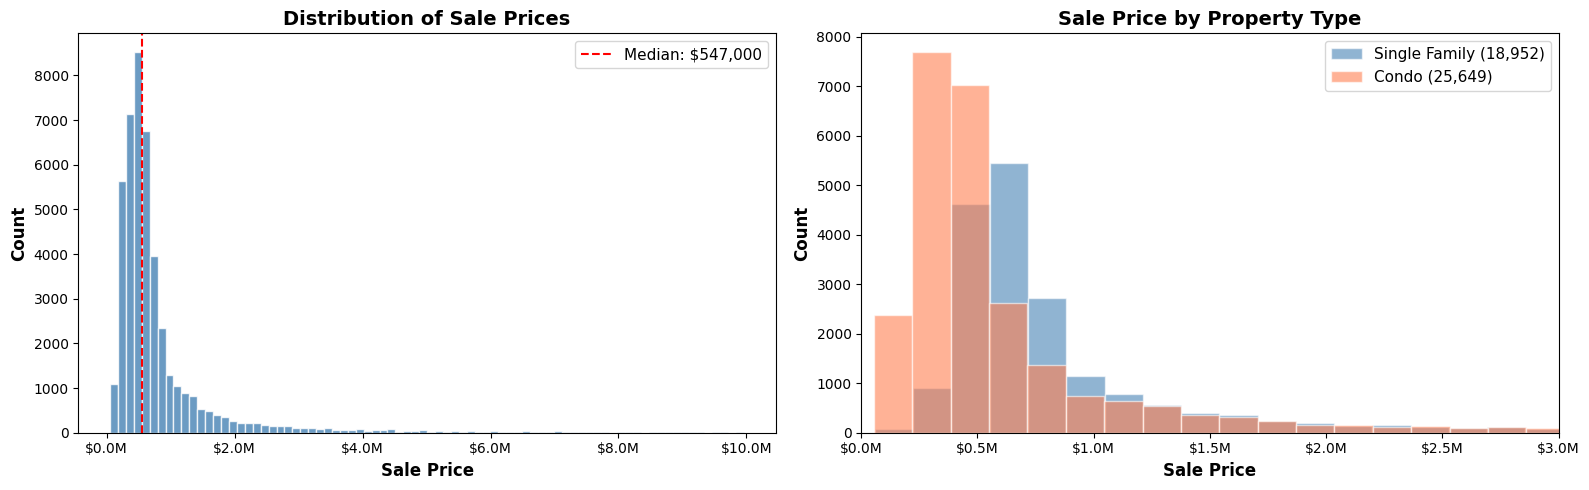

In [ ]:
# ── EDA: Distribution of Sale Prices ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of sale prices
ax1 = axes[0]
ax1.hist(features['sale_price'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax1.set_xlabel('Sale Price', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Sale Prices', fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax1.axvline(features['sale_price'].median(), color='red', linestyle='--',
            label=f"Median: ${features['sale_price'].median():,.0f}")
ax1.legend(fontsize=11)

# Sale price by property type
ax2 = axes[1]
condo_prices = features[features['is_condo'] == 1]['sale_price']
sfh_prices = features[features['is_condo'] == 0]['sale_price']
ax2.hist(sfh_prices, bins=60, alpha=0.6, color='steelblue', label=f'Single Family ({len(sfh_prices):,})', edgecolor='white')
ax2.hist(condo_prices, bins=60, alpha=0.6, color='coral', label=f'Condo ({len(condo_prices):,})', edgecolor='white')
ax2.set_xlabel('Sale Price', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Sale Price by Property Type', fontsize=14, fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax2.set_xlim(0, 3_000_000)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

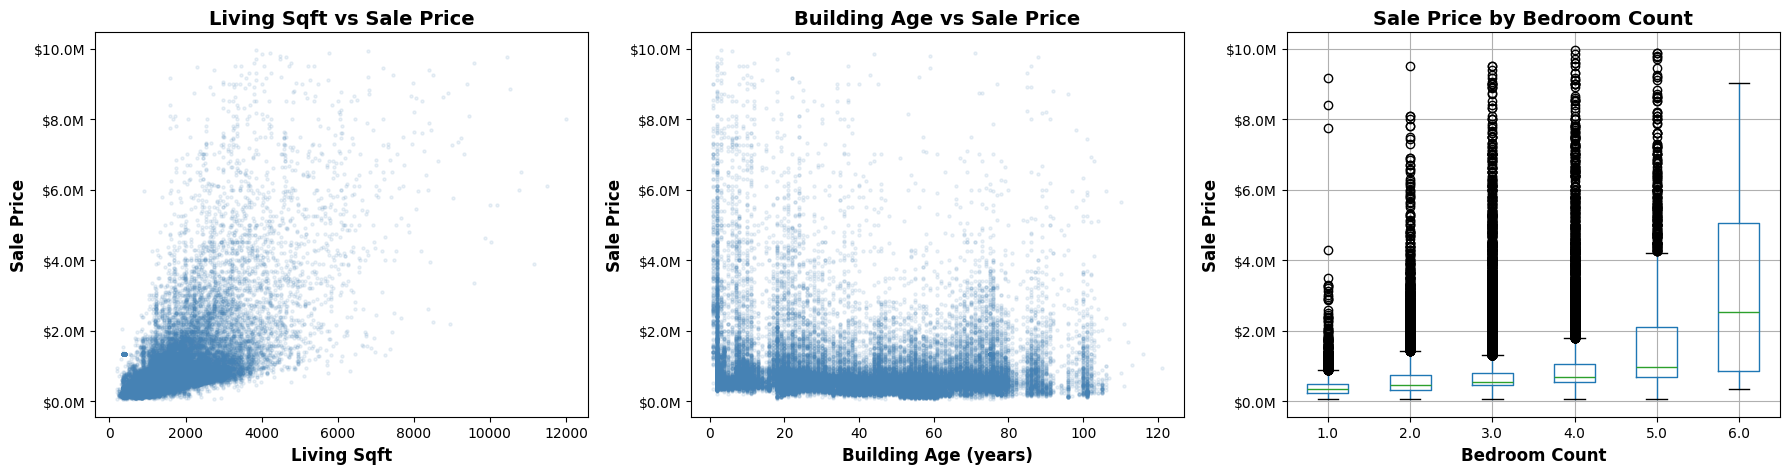

In [ ]:
# ── EDA: Key Relationships with Sale Price ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Living sqft vs sale price
ax1 = axes[0]
ax1.scatter(features['living_sqft'], features['sale_price'], alpha=0.1, s=5, color='steelblue')
ax1.set_xlabel('Living Sqft', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
ax1.set_title('Living Sqft vs Sale Price', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Building age vs sale price
ax2 = axes[1]
ax2.scatter(features['building_age'], features['sale_price'], alpha=0.1, s=5, color='steelblue')
ax2.set_xlabel('Building Age (years)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
ax2.set_title('Building Age vs Sale Price', fontsize=14, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Bedrooms vs sale price (boxplot)
ax3 = axes[2]
bed_data = features[features['Bedroom Count'].between(1, 6)]
bed_data.boxplot(column='sale_price', by='Bedroom Count', ax=ax3)
ax3.set_xlabel('Bedroom Count', fontsize=12, fontweight='bold')
ax3.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
ax3.set_title('Sale Price by Bedroom Count', fontsize=14, fontweight='bold')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
plt.suptitle('')

plt.tight_layout()
plt.show()

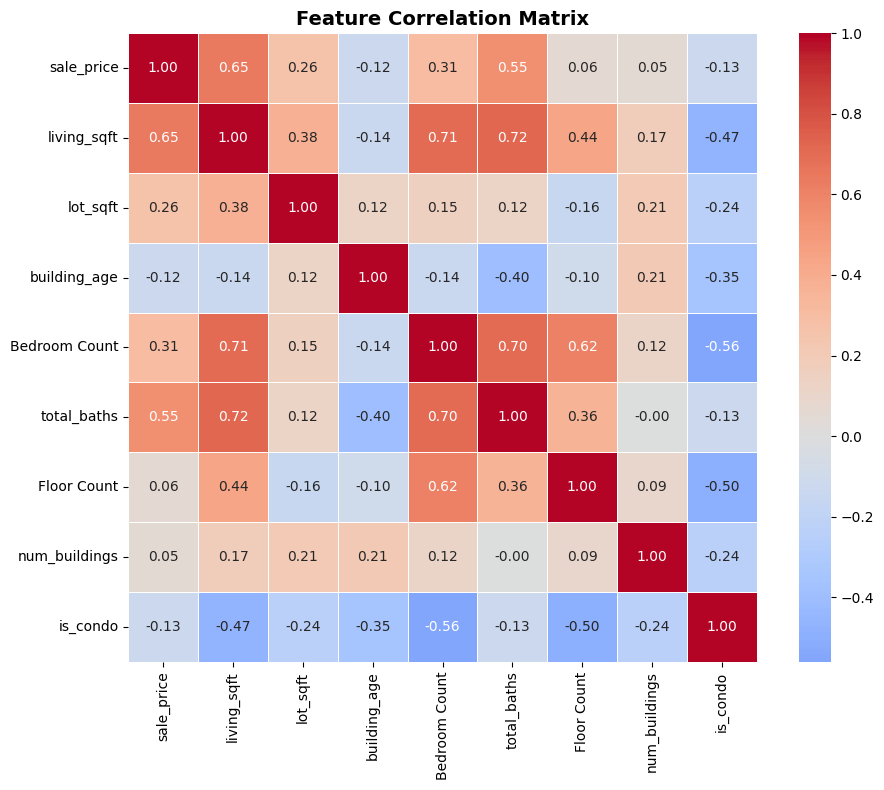

Correlation with sale_price:
sale_price       1.000000
living_sqft      0.645922
total_baths      0.551594
Bedroom Count    0.307560
lot_sqft         0.260588
Floor Count      0.056783
num_buildings    0.053315
building_age    -0.122467
is_condo        -0.127468


In [ ]:
# ── EDA: Correlation Heatmap ──
# Shows how strongly each numeric feature correlates with sale price.
# Values close to 1 = strong positive relationship,
# close to -1 = strong negative, close to 0 = weak/no relationship.

corr_cols = ['sale_price', 'living_sqft', 'lot_sqft', 'building_age',
             'Bedroom Count', 'total_baths', 'Floor Count',
             'num_buildings', 'is_condo']

corr_matrix = features[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlations with sale price specifically
print("Correlation with sale_price:")
print(corr_matrix['sale_price'].sort_values(ascending=False).to_string())

In [ ]:
# ── EDA: Top Zip Codes ──
print("Top 15 zip codes by sales volume:")
print(features['zip_code'].value_counts().head(15))
print(f"\nTotal unique zip codes: {features['zip_code'].nunique()}")

# Median price by top zip codes
top_zip_prices = features[features['top_zip'] != 'other'].groupby('top_zip')['sale_price'].median().sort_values(ascending=False)
print(f"\nMedian sale price by top zip code:")
for z, p in top_zip_prices.items():
    print(f"  {z}: ${p:,.0f}")

Top 15 zip codes by sales volume:
zip_code
33160.0    2088
33139.0    1987
33131.0    1484
33033.0    1462
33032.0    1338
33132.0    1292
33180.0    1179
33133.0    1130
33178.0    1100
33157.0    1022
33141.0    1004
33186.0     972
33034.0     889
33035.0     841
33179.0     839
Name: count, dtype: int64

Total unique zip codes: 78

Median sale price by top zip code:
  33133: $1,327,500
  33131: $822,500
  33160: $675,000
  33157: $664,500
  33178: $600,000
  33132: $560,000
  33186: $545,000
  33180: $515,000
  33032: $480,000
  33139: $476,000
  33033: $455,000
  33141: $445,000
  33035: $420,000
  33034: $415,000
  33179: $260,000


---
## Phase 5: Model Training & Evaluation
Train a Random Forest model on the full feature set, filtering to properties under $2M for better performance on typical homes.

In [ ]:
# ── Define features (X) and target (y) ──
#
# y = the target variable (what I am predicting): sale_price
# X = the feature matrix (what I feed the model to make predictions)
#
# IMPORTANT: I deliberately EXCLUDE just_value, land_value, and price_per_sqft.
# just_value has a 0.98 correlation with sale_price — if I included it, the model
# would essentially be cheating by using the county's own appraisal to predict
# the sale price. We only use features that would be known BEFORE a sale happens.

feature_cols = ['living_sqft', 'lot_sqft', 'eff_age',
                'num_buildings', 'is_condo', 'Bedroom Count',
                'total_baths', 'Floor Count', 'sqft_per_bedroom', 'bath_bed_ratio']

# pd.get_dummies() converts a categorical column into binary (0/1) columns.
# This is called "one-hot encoding." drop_first=True avoids multicollinearity
# by dropping one category (it becomes the baseline).
zip_dummies = pd.get_dummies(features['top_zip'], prefix='zip', drop_first=True)

age_dummies = pd.get_dummies(features['age_tier'], prefix='age', drop_first=True)

# pd.concat() joins DataFrames side-by-side (axis=1 = columns).
X = pd.concat([features[feature_cols], zip_dummies, age_dummies], axis=1)

# Fill any remaining NaN values with the column median
X = X.fillna(X.median())
y = features['sale_price']

# ── Filter to properties under $2M ──
# Miami has extreme outliers ($5M+ homes) that distort the model.
# Filtering to <$2M covers ~95% of properties and dramatically improves
# accuracy on typical homes.
mask = y <= 2_000_000
X = X[mask]
y = y[mask]

print(f"Properties under $2M: {mask.sum():,} / {len(features):,} ({mask.sum()/len(features)*100:.1f}%)")
print(f"Feature matrix: {X.shape[0]:,} rows, {X.shape[1]} features")
print(f"\nFeatures used: {list(X.columns[:11])} + {X.shape[1] - 11} zip code dummies")

Properties under $2M: 41,508 / 44,601 (93.1%)
Feature matrix: 41,508 rows, 28 features

Features used: ['living_sqft', 'lot_sqft', 'eff_age', 'num_buildings', 'is_condo', 'Bedroom Count', 'total_baths', 'Floor Count', 'sqft_per_bedroom', 'bath_bed_ratio', 'zip_33033'] + 17 zip code dummies


In [ ]:
# ── Train/Test Split ──
# I hold out 20% of the data as a "test set" that the model never sees
# during training. This lets me evaluate how well it generalizes to new data.
#
# random_state=42: makes the split reproducible (same split every time)
# test_size=0.20: 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} records")
print(f"Testing set:  {X_test.shape[0]:,} records")

Training set: 33,206 records
Testing set:  8,302 records


In [ ]:
# ── Train the Random Forest Model ──
# Random Forest is an "ensemble" method: it builds hundreds of decision trees,
# each trained on a random subset of data, and averages their predictions.
# This reduces overfitting and usually gives strong results on tabular data.
#
# Key parameters:
#   n_estimators=300:    number of trees in the forest (more = better but slower)
#   max_depth=25:        how deep each tree can grow (controls complexity)
#   min_samples_leaf=3:  minimum records in each leaf node (prevents overfitting)
#   random_state=42:     makes results reproducible
#   n_jobs=-1:           use all CPU cores for parallel training

print("Training Random Forest...")
start = time.time()

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

# .fit() trains the model: it learns patterns from X_train to predict y_train
rf.fit(X_train, y_train)

# .predict() uses the trained model to estimate prices for data it hasn't seen
rf_preds = rf.predict(X_test)

rf_time = time.time() - start

# ── Evaluate ──
# R² (R-squared): measures how much of the price variation my model explains.
#   1.0 = perfect predictions, 0.0 = no better than guessing the average.
# MAE (Mean Absolute Error): average dollar amount the prediction is off by.

rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)

print(f"\n{'='*50}")
print(f"RANDOM FOREST RESULTS")
print(f"{'='*50}")
print(f"  R² Score:        {rf_r2:.4f}")
print(f"  MAE:             ${rf_mae:,.0f}")
print(f"  Median Price:    ${y.median():,.0f}")
print(f"  MAE as % of Median: {rf_mae/y.median()*100:.1f}%")
print(f"  Training Time:   {rf_time:.1f}s")

Training Random Forest...

RANDOM FOREST RESULTS
  R² Score:        0.7721
  MAE:             $99,063
  Median Price:    $523,000
  MAE as % of Median: 18.9%
  Training Time:   48.1s


---
## Phase 6: Model Visualization & Analysis
Visualizing model performance and understand what features drive predictions.

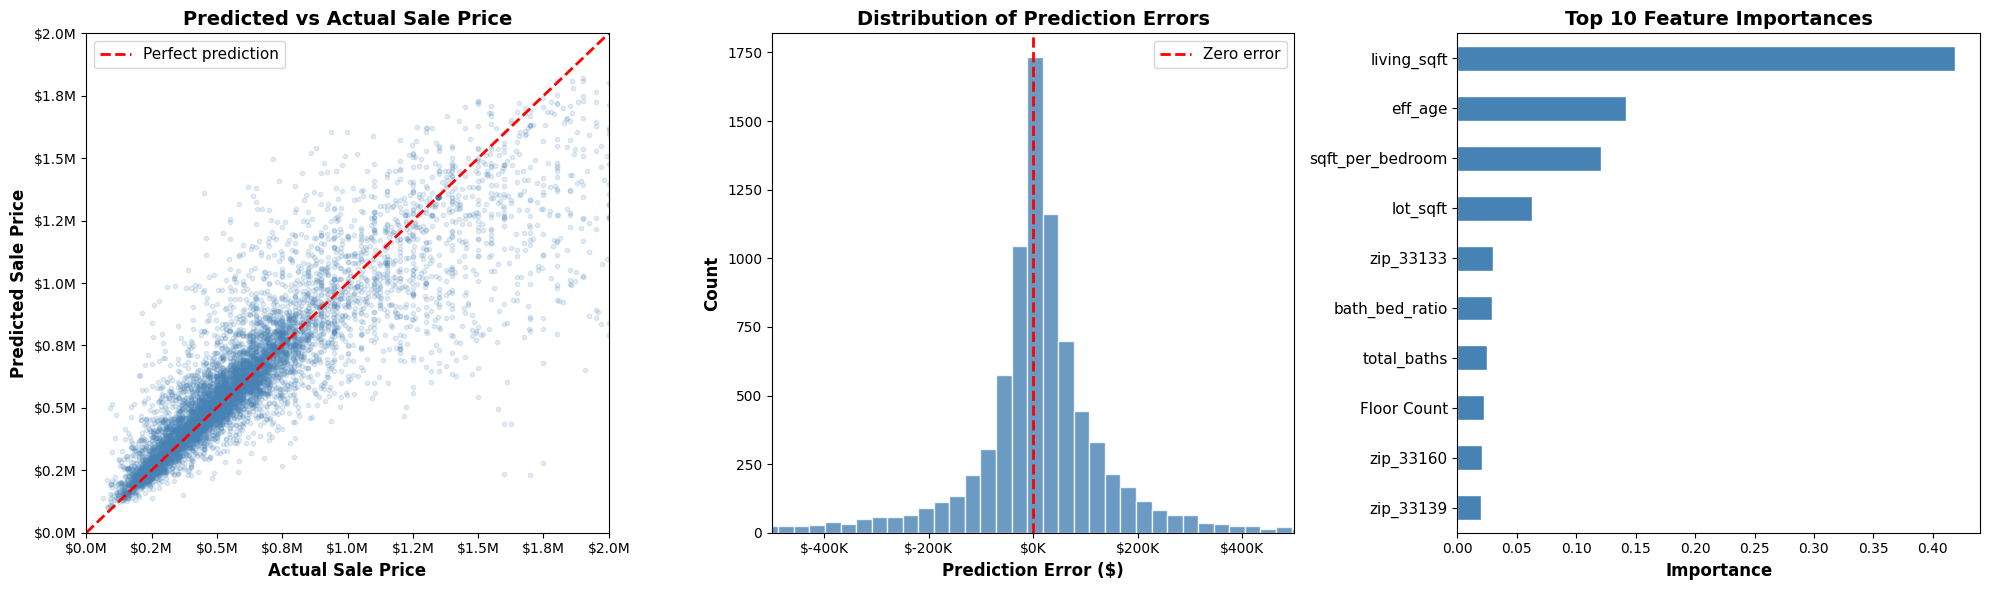


Visualization saved to Google Drive.


In [ ]:
# ── Final Visualizations ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Predicted vs Actual
# Points along the red dashed line = perfect predictions.
# Scatter above the line = model over-predicted, below = under-predicted.
ax1 = axes[0]
ax1.scatter(y_test, rf_preds, alpha=0.15, s=10, color='steelblue')
ax1.plot([0, 2_000_000], [0, 2_000_000], 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Sale Price', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Sale Price', fontsize=12, fontweight='bold')
ax1.set_title('Predicted vs Actual Sale Price', fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax1.legend(fontsize=11)
ax1.set_xlim(0, 2_000_000)
ax1.set_ylim(0, 2_000_000)

# Plot 2: Error Distribution
# Centered around zero = model is not biased (doesn't consistently over/under-predict)
ax2 = axes[1]
errors = rf_preds - y_test
ax2.hist(errors, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax2.set_xlabel('Prediction Error ($)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))
ax2.set_xlim(-500_000, 500_000)
ax2.legend(fontsize=11)

# Plot 3: Feature Importance
# Shows which features the model relies on most to make predictions.
# Higher importance = bigger impact on the predicted price.
ax3 = axes[2]
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_10 = importances.sort_values(ascending=True).tail(10)
top_10.plot(kind='barh', ax=ax3, color='steelblue', edgecolor='white')
ax3.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax3.set_title('Top 10 Feature Importances', fontsize=14, fontweight='bold')
ax3.set_yticklabels(ax3.get_yticklabels(), fontsize=11)

plt.tight_layout()
plt.savefig(path + 'model_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved to Google Drive.")

In [ ]:
# ── Feature Importance Breakdown ──
print("Full Feature Importance Ranking:")
print("=" * 45)
for feat, imp in importances.sort_values(ascending=False).items():
    if imp >= 0.005:  # Only show features with >= 0.5% importance
        bar = '█' * int(imp * 50)
        print(f"  {feat:25s} {imp:6.1%}  {bar}")

Full Feature Importance Ranking:
  living_sqft                41.9%  ████████████████████
  eff_age                    14.2%  ███████
  sqft_per_bedroom           12.1%  ██████
  lot_sqft                    6.3%  ███
  zip_33133                   3.0%  █
  bath_bed_ratio              2.9%  █
  total_baths                 2.5%  █
  Floor Count                 2.3%  █
  zip_33160                   2.1%  █
  zip_33139                   2.0%  
  zip_33131                   1.9%  
  age_Historic                1.5%  
  zip_other                   1.1%  
  is_condo                    0.9%  
  zip_33132                   0.8%  
  zip_33178                   0.8%  
  age_Mid_Century             0.8%  
  zip_33141                   0.6%  


In [ ]:
import json

with open('/content/drive/MyDrive/model_columns.json', 'w') as f:
    json.dump(list(X.columns), f)
print("Total columns:", len(X.columns))
print(list(X.columns))

Total columns: 28
['living_sqft', 'lot_sqft', 'eff_age', 'num_buildings', 'is_condo', 'Bedroom Count', 'total_baths', 'Floor Count', 'sqft_per_bedroom', 'bath_bed_ratio', 'zip_33033', 'zip_33034', 'zip_33035', 'zip_33131', 'zip_33132', 'zip_33133', 'zip_33139', 'zip_33141', 'zip_33157', 'zip_33160', 'zip_33178', 'zip_33179', 'zip_33180', 'zip_33186', 'zip_other', 'age_Modern', 'age_Mid_Century', 'age_Historic']


In [ ]:
import joblib

#Saving the trained Random Forest model to Google Drive
joblib.dump(rf, '/content/drive/MyDrive/rf_model.joblib')
print("Model saved!")

Model saved!


In [ ]:
import joblib
import os

# Save with compression (reduces file size significantly)
joblib.dump(rf, '/content/drive/MyDrive/rf_model_compressed.joblib', compress=3)

# Check sizes
original = os.path.getsize('/content/drive/MyDrive/rf_model.joblib') / (1024*1024)
compressed = os.path.getsize('/content/drive/MyDrive/rf_model_compressed.joblib') / (1024*1024)
print(f"Original:   {original:.1f} MB")
print(f"Compressed: {compressed:.1f} MB")

Original:   195.8 MB
Compressed: 56.1 MB


In [ ]:
import json

# Saving the feature names so the Sreamlit app knows what the model expects
with open('/content/drive/MyDrive/model_features.json', 'w') as f:
  json.dump(feature_cols, f)
print("Feature names saved:", feature_cols)


Feature names saved: ['living_sqft', 'lot_sqft', 'eff_age', 'num_buildings', 'is_condo', 'Bedroom Count', 'total_baths', 'Floor Count', 'sqft_per_bedroom', 'bath_bed_ratio']


In [ ]:
rf_lite = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_lite.fit(X_train, y_train)
lite_preds = rf_lite.predict(X_test)

print(f"R²:  {r2_score(y_test, lite_preds):.4f}")
print(f"MAE: ${mean_absolute_error(y_test, lite_preds):,.0f}")

# Saving with heavy compression
joblib.dump(rf_lite, '/content/drive/MyDrive/rf_model.joblib', compress=5)
size = os.path.getsize('/content/drive/MyDrive/rf_model.joblib') / (1024*1024)
print(f"File size: {size:.1f} MB")

R²:  0.7674
MAE: $100,893
File size: 13.8 MB


---
## Summary

**Dataset:** 44,000+ Miami-Dade residential property sales (single family + condos) from Florida DOR and Miami-Dade open data.

**Model:** Random Forest Regressor (300 trees, max depth 25) trained on properties under $2M.

**Features used:** living sqft, lot sqft, building age, effective age, number of buildings, bedrooms, total bathrooms, floors, sqft per bedroom, bath-to-bed ratio, condo flag, and zip code dummies (top 15).

**Key decisions:**
- Excluded assessed value (just_value) to avoid data leakage
- Sourced bedroom/bathroom data from a separate Miami-Dade dataset (99.8% match rate)
- Filtered to properties under $2M to focus on the typical market segment
- Engineered interaction features (sqft_per_bedroom, bath_bed_ratio) that improved model performance
